In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt


In [2]:
class ZeroImputerTransformer(BaseEstimator, TransformerMixin):
    
    def __init__(self, columns):
        self.columns = columns
        self.learned_median = {}
        
    def fit(self, X, y=None):
        
        for col in self.columns:
            self.learned_median[col] = X[col].median()
            
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        
        for col in self.columns:
            X_copy[col] = X_copy[col].fillna(self.learned_median[col])
            
        return X_copy

In [11]:
df = pd.read_csv("diabetes-k-nn.csv")

X = df.drop('Outcome', axis=1)
y = df['Outcome']

print((df == 0).sum())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [4]:


contains_zero_feat = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

preprocess = ColumnTransformer(
    transformers = [
        ('imputer', ZeroImputerTransformer(columns=contains_zero_feat), contains_zero_feat)
    ],
    remainder = "passthrough"
)

pipeline = Pipeline([
    ('zeroimputer', preprocess),
    ('preprocessing', StandardScaler()),
    ('classifier', KNeighborsClassifier())
])

param_grid = {
    'classifier__n_neighbors' : [3, 5, 7]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

In [5]:
grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during f

In [6]:
predictions = grid_search.predict(X_test)

print(predictions)

[1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 1 1 1 1 0 0 0 0 1 0 0 0 1 1 1 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 1 1 1 0 0 0 0 0 1 0 1 0 1 1 0
 1 1 0 0 0 0 0 1 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1 0
 0 0 0 0 1 0]


In [29]:
grid_search.cv_results_

grid_search_df = pd.DataFrame(grid_search.cv_results_)
gs_score = grid_search_df[['param_classifier__n_neighbors', 'mean_test_score', 'std_test_score']]
gs_score = gs_score.sort_values(by="param_classifier__n_neighbors")

best_k = gs_score.iloc[gs_score['mean_test_score'].idxmax()]
worst_k = gs_score.iloc[gs_score['mean_test_score'].idxmin()]

print("\n\n", classification_report(y_test, predictions))

print("\n",gs_score)

print(f"\nBest K :\n{best_k}")
print(f"\nWorst K :\n{worst_k}")



               precision    recall  f1-score   support

           0       0.75      0.80      0.78       100
           1       0.58      0.52      0.55        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154


    param_classifier__n_neighbors  mean_test_score  std_test_score
0                              3         0.528239        0.045407
1                              5         0.565227        0.057639
2                              7         0.551606        0.045513

Best K :
param_classifier__n_neighbors    5.000000
mean_test_score                  0.565227
std_test_score                   0.057639
Name: 1, dtype: float64

Worst K :
param_classifier__n_neighbors    3.000000
mean_test_score                  0.528239
std_test_score                   0.045407
Name: 0, dtype: float64


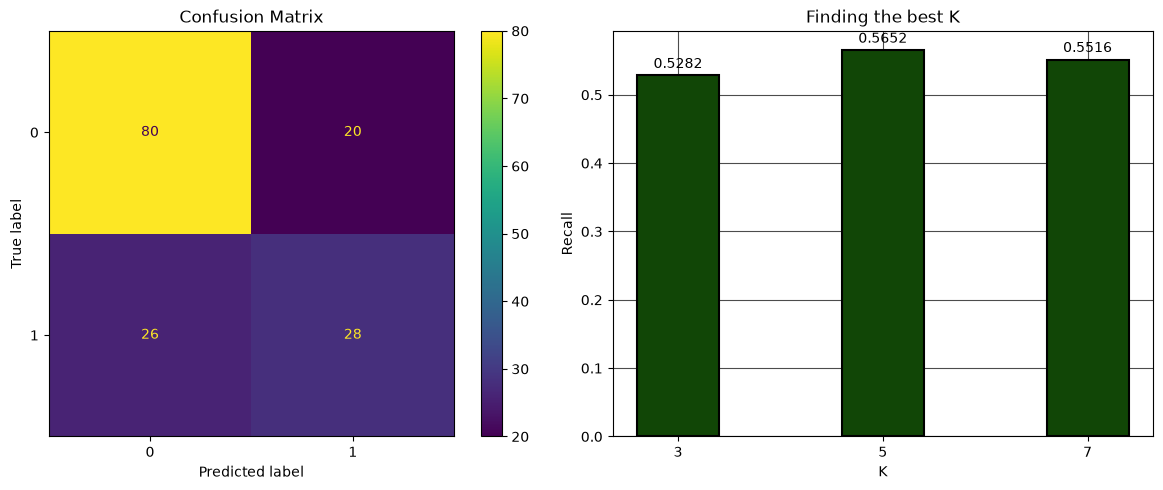

In [26]:
# VISUALIZATION's
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=axes[0])
axes[0].set_title("Confusion Matrix")

bar = axes[1].bar(gs_score['param_classifier__n_neighbors'], gs_score['mean_test_score'], color="#114606", edgecolor="#000000", linewidth=1.5)
axes[1].set_xticks(gs_score['param_classifier__n_neighbors'])
axes[1].set_xlabel("K")
axes[1].set_ylabel("Recall")
axes[1].set_title("Finding the best K")
axes[1].grid(True, alpha=0.7, color="#000000")
axes[1].set_axisbelow(True)
axes[1].bar_label(bar, padding=3, fmt="%.4f")

plt.tight_layout()
plt.show()